# Here we work with all the PCA + Clustering methods to visualise our data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [13]:
df_scaled = pd.read_csv(r"data\claims_train_scaled.csv")
df_scaled.head()


,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,0,0.43,D,0.266880,1.974647,-0.672262,2.259081,B1,Regular,-0.187042,R24
1,0,0.10,D,0.266880,1.794735,2.445658,2.259081,B2,Regular,-0.302036,R25
2,0,0.33,E,0.266880,-0.724035,-0.672262,1.041179,B6,Regular,0.599254,R82
3,0,0.56,A,-0.708699,-0.544123,1.949625,-0.497224,B13,Diesel,-0.449057,R24
4,0,0.27,E,0.754669,-1.263772,-0.601401,-0.625424,B11,Diesel,0.308995,R53


In [14]:
df_scaled.drop(columns=["Area","VehBrand","VehGas","Region"],inplace=True)

In [15]:
pca_claims = PCA()
pca_claims.fit(df_scaled)
scores = pca_claims.transform(df_scaled)

In [16]:
#the original dataset
df_original = pd.read_csv("data\claims_train_final.csv")
df_original.drop(columns=["Area","VehBrand","VehGas","Region"],inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\khatt\AppData\Local\Temp\ipykernel_14472\1396806940.py:2: SyntaxWarning: invalid escape sequence '\c'
  df_original = pd.read_csv("data\claims_train_final.csv")


In [17]:
df_original.head()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
0,0,0.43,7,18,36,95,1054
1,0,0.10,7,17,80,95,598
2,0,0.33,7,3,36,76,4172
3,0,0.56,5,4,73,52,15
4,0,0.27,8,0,37,50,3021


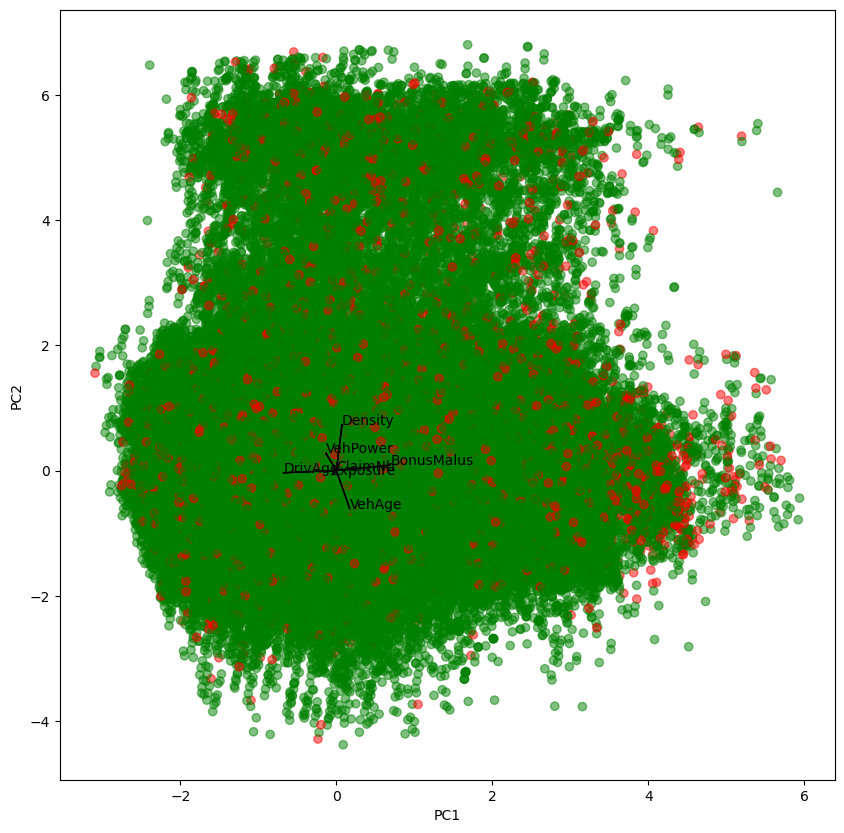

In [19]:
#making a biplot
i, j = 0, 1 # which components 
colors = np.where(df_original['ClaimNb'] == 0, 'green', 'red')
fig, ax = plt.subplots(1, 1, figsize=(10, 10)) 
ax.scatter(scores[:,0], scores[:,1],c=colors,alpha=0.5) 
ax.set_xlabel('PC%d' % (i+1)) 
ax.set_ylabel('PC%d' % (j+1)) 
for k in range(pca_claims.components_.shape[1]):
    ax.arrow(0, 0, pca_claims.components_[i,k], pca_claims.components_[j,k]) 
    ax.text(pca_claims.components_[i,k], pca_claims.components_[j,k], df_original.columns[k])